In [ ]:
import kagglehub

In [96]:

# Download latest version
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\PC\.cache\kagglehub\datasets\fedesoriano\stroke-prediction-dataset\versions\1


Imported the dataset directly from kagglehub

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
dp = pd.read_csv(path + "/healthcare-dataset-stroke-data.csv")
dp

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [99]:
dp.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [100]:
dp.dtypes

id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

Had a view of the dataset.
12 columns, each with its data type. Floats (age, bmi, avg_glucose_level), Integers (id, hypertension, heart_disease, stroke), and Strings (gender, ever_married, smoking_status, work_type, residence_type).

Our taget is stroke column.

In [101]:
dp.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


Noticed only bmi has null values

In [102]:
for col in dp.columns:
    print(f"  {col}: {dp[col].nunique()} unique values")

  id: 5110 unique values
  gender: 3 unique values
  age: 104 unique values
  hypertension: 2 unique values
  heart_disease: 2 unique values
  ever_married: 2 unique values
  work_type: 5 unique values
  Residence_type: 2 unique values
  avg_glucose_level: 3979 unique values
  bmi: 418 unique values
  smoking_status: 4 unique values
  stroke: 2 unique values



Checked for unique values, noticed gender to have 3 wch is weird
I will go ahead and do its value count, I will do same for all string column to be on the safe side.


In [103]:
for col in dp.select_dtypes(include='string').columns:
    print(f"\n{col}:")
    print(dp[col].value_counts())


# Descriptive statistics of categorical columns


gender:
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

ever_married:
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

work_type:
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Residence_type:
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

smoking_status:
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


Found 'other' under gender and just one of it, better to drop it before modelling.
Discovered 'Unknown' to be 1544 under smoking_status, not NaN tho.

# Going ahead to check for missing values


In [104]:
missing = dp.isnull().sum()
missing_pct = (dp.isnull().sum() / len(dp)) * 100
missing_dp = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print(missing_dp[missing_dp['Missing Count'] > 0])

     Missing Count  Missing %
bmi            201       3.93


Lets visualize the missing values

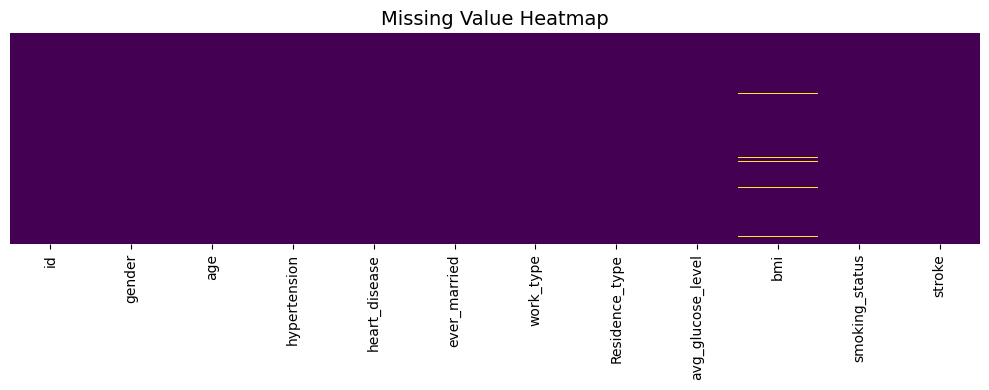

In [105]:
plt.figure(figsize=(10, 4))
sns.heatmap(dp.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

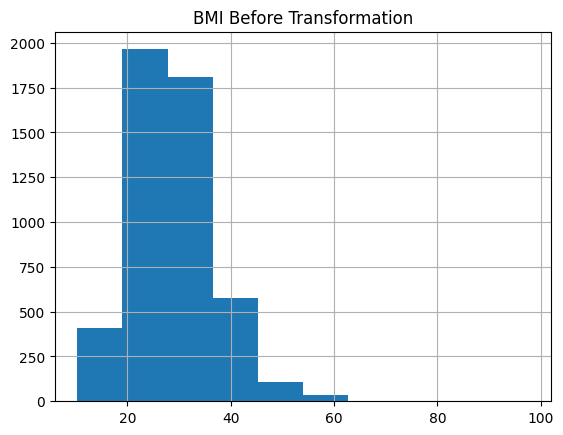

In [106]:
dp['bmi'].hist()
plt.title("BMI Before Transformation")
plt.show()

Will handle the missing values by using median since its not symmetrical

In [107]:
dp.loc[dp['bmi'].isna(), 'bmi'] = dp['bmi'].median()
# Modification of original dataframe.

In [108]:
print(f"\nBMI missing values after imputation: {dp['bmi'].isnull().sum()}")
print(f"Total missing values remaining: {dp.isnull().sum().sum()}")



BMI missing values after imputation: 0
Total missing values remaining: 0


Let's check the descriptive statistics

In [109]:
# for numeric columns.
print(dp.describe().round(2))

             id      age  hypertension  heart_disease  avg_glucose_level  \
count   5110.00  5110.00        5110.0        5110.00            5110.00   
mean   36517.83    43.23           0.1           0.05             106.15   
std    21161.72    22.61           0.3           0.23              45.28   
min       67.00     0.08           0.0           0.00              55.12   
25%    17741.25    25.00           0.0           0.00              77.24   
50%    36932.00    45.00           0.0           0.00              91.88   
75%    54682.00    61.00           0.0           0.00             114.09   
max    72940.00    82.00           1.0           1.00             271.74   

           bmi   stroke  
count  5110.00  5110.00  
mean     28.86     0.05  
std       7.70     0.22  
min      10.30     0.00  
25%      23.80     0.00  
50%      28.10     0.00  
75%      32.80     0.00  
max      97.60     1.00  


In [110]:
# skewness for numeric columns
num_cols = ['age', 'avg_glucose_level', 'bmi']
for col in num_cols:
    print(f"  {col}: skewness = {dp[col].skew():.4f}")


  age: skewness = -0.1371
  avg_glucose_level: skewness = 1.5723
  bmi: skewness = 1.0882


Next in line is Univariate analysis and visualization
Examining each feature individually

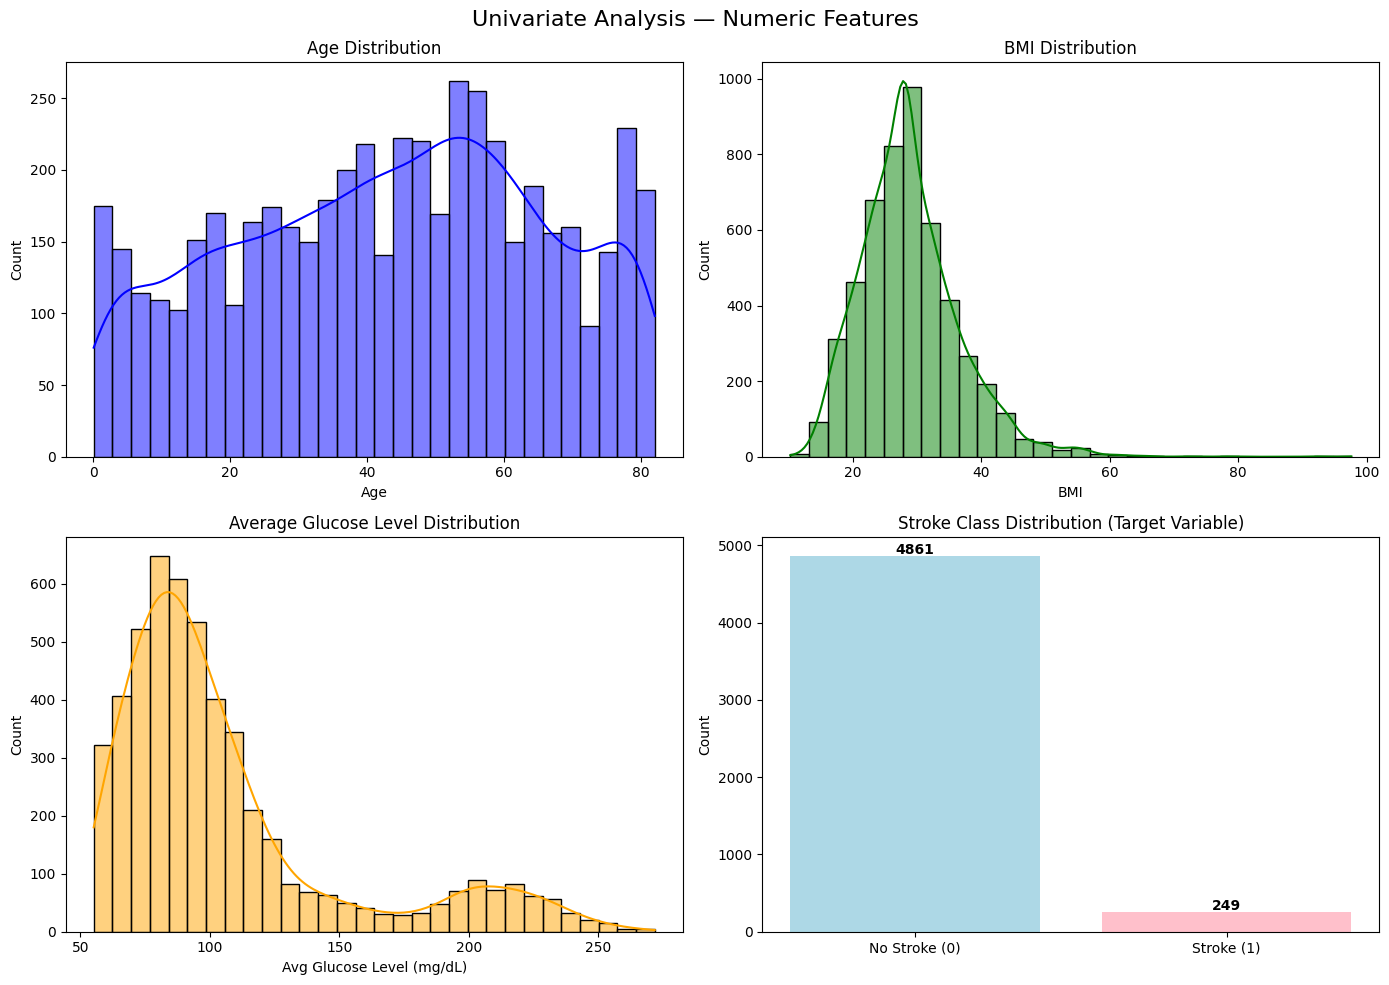

In [111]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Univariate Analysis — Numeric Features', fontsize=16)

# Age distribution
sns.histplot(dp['age'], bins=30, kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')

# BMI distribution
sns.histplot(dp['bmi'], bins=30, kde=True, ax=axes[0, 1], color='green')
axes[0, 1].set_title('BMI Distribution')
axes[0, 1].set_xlabel('BMI')

# Glucose level distribution
sns.histplot(dp['avg_glucose_level'], bins=30, kde=True,
             ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Average Glucose Level Distribution')
axes[1, 0].set_xlabel('Avg Glucose Level (mg/dL)')

# Stroke class balance
stroke_counts = dp['stroke'].value_counts()
axes[1, 1].bar(['No Stroke (0)', 'Stroke (1)'],
               stroke_counts.values,
               color=['lightblue', 'pink'])
axes[1, 1].set_title('Stroke Class Distribution (Target Variable)')
axes[1, 1].set_ylabel('Count')
for i, v in enumerate(stroke_counts.values):
    axes[1, 1].text(i, v + 30, str(v), ha='center', fontweight='bold')

    plt.tight_layout()
plt.show()

Observations
Age is fairly uniform 
BMI and glucose are both right-skewed
Stroke target is severely imbalanced, need to be careful during train_test_split 

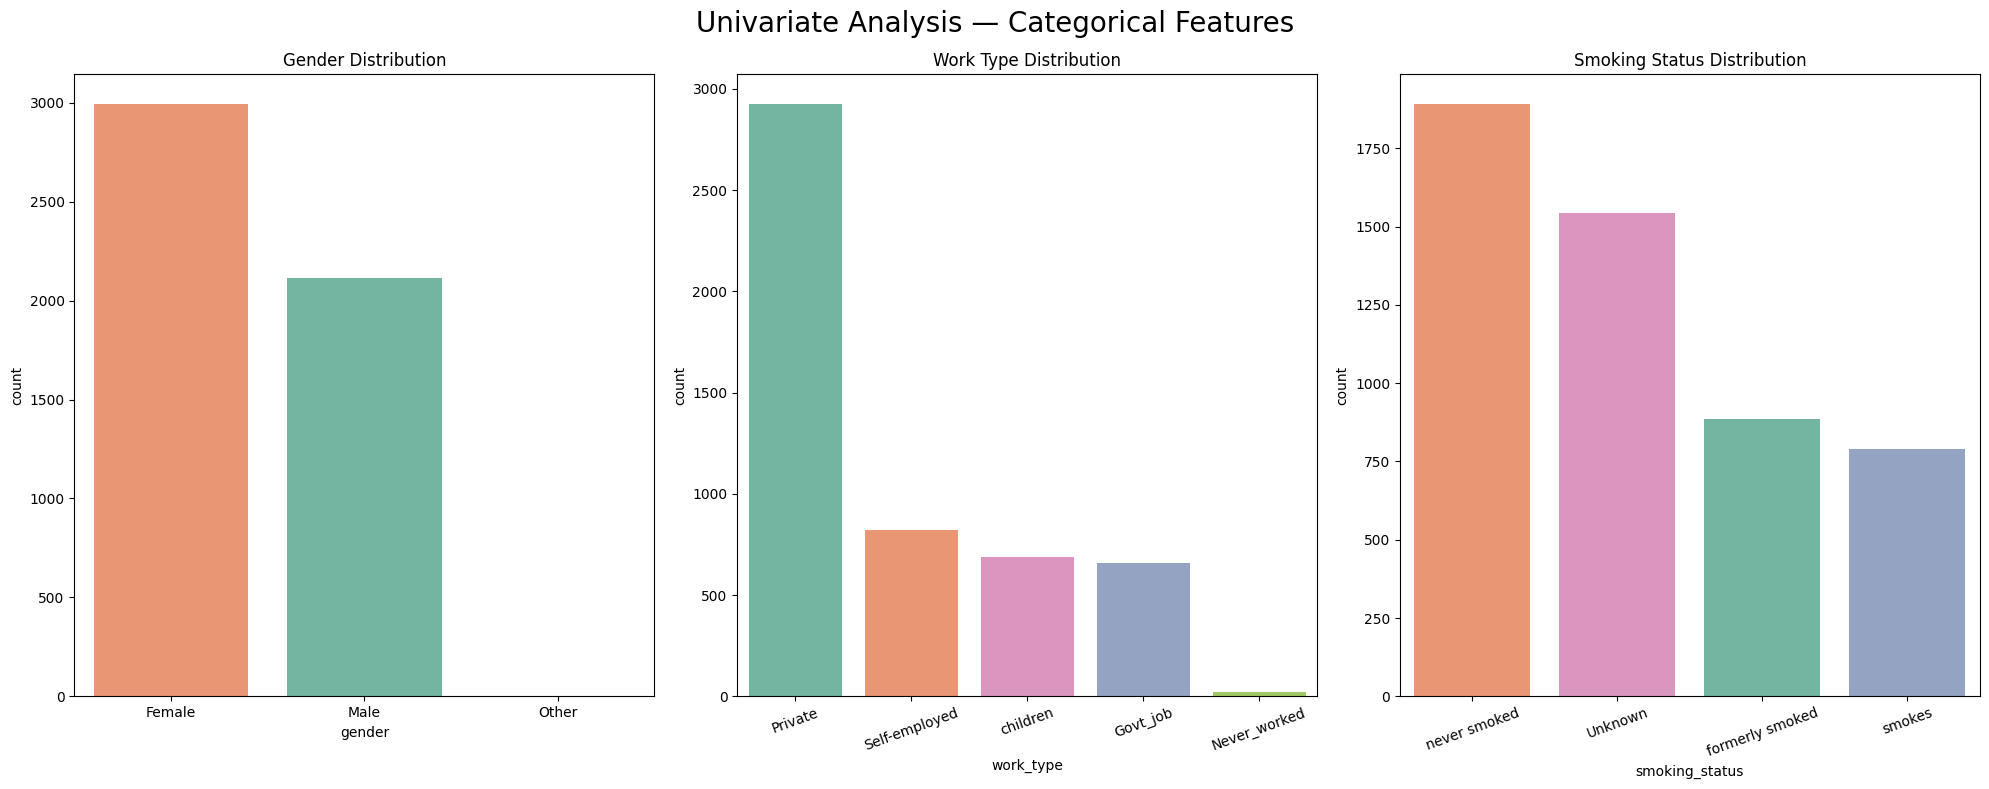

In [112]:
# Categorical features
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Univariate Analysis — Categorical Features', fontsize=20)

sns.countplot(data=dp, x='gender', ax=axes[0],
              palette='Set2', hue='gender', legend=False, order=dp['gender'].value_counts().index)
axes[0].set_title('Gender Distribution')

sns.countplot(data=dp, x='work_type', ax=axes[1],
              palette='Set2', hue='work_type', legend=False, order=dp['work_type'].value_counts().index)
axes[1].set_title('Work Type Distribution')
axes[1].tick_params(axis='x', rotation=20)

sns.countplot(data=dp, x='smoking_status', ax=axes[2],
              palette='Set2', hue='smoking_status', legend=False, order=dp['smoking_status'].value_counts().index)
axes[2].set_title('Smoking Status Distribution')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

Observations
Private sector is the dominant work type
'Never smoked' is the most common smoking status
There is 1 person with gender 'Other', needs to be dropped

Bivariate analysis and visualization
This step reveals which features have a meaningful relationship with the target variable (stroke), guiding feature selection decisions.

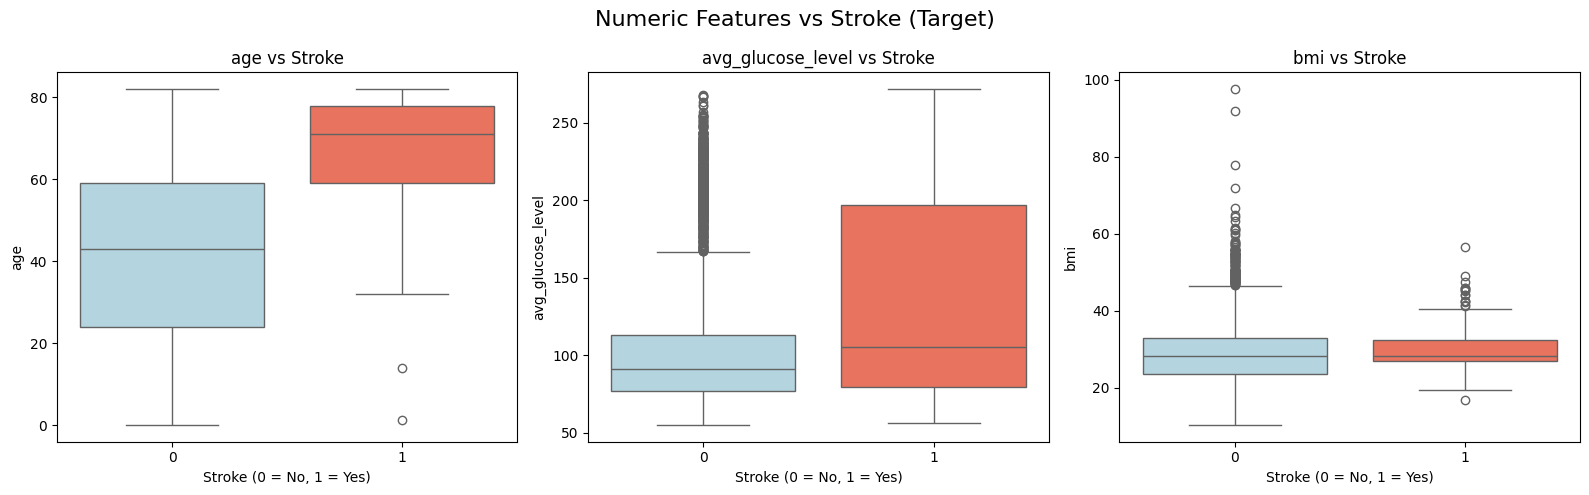

In [113]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Numeric Features vs Stroke (Target)', fontsize=16)

for ax, col, color in zip(axes,
                           ['age', 'avg_glucose_level', 'bmi'],
                           ['steelblue', 'mediumseagreen', 'salmon']):
    sns.boxplot(data=dp, x='stroke', y=col, ax=ax,
                palette={0: 'lightblue', 1: 'tomato'}, hue='stroke', legend=False)
    ax.set_title(f'{col} vs Stroke')
    ax.set_xlabel('Stroke (0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()


Observations
Age: stroke patients are significantly older (median ~70) vs non-stroke (~43). Age is the strongest individual predictor.
Glucose: stroke patients have higher glucose levels on average, suggesting a link with diabetes.
BMI: modest difference between groups, not significant

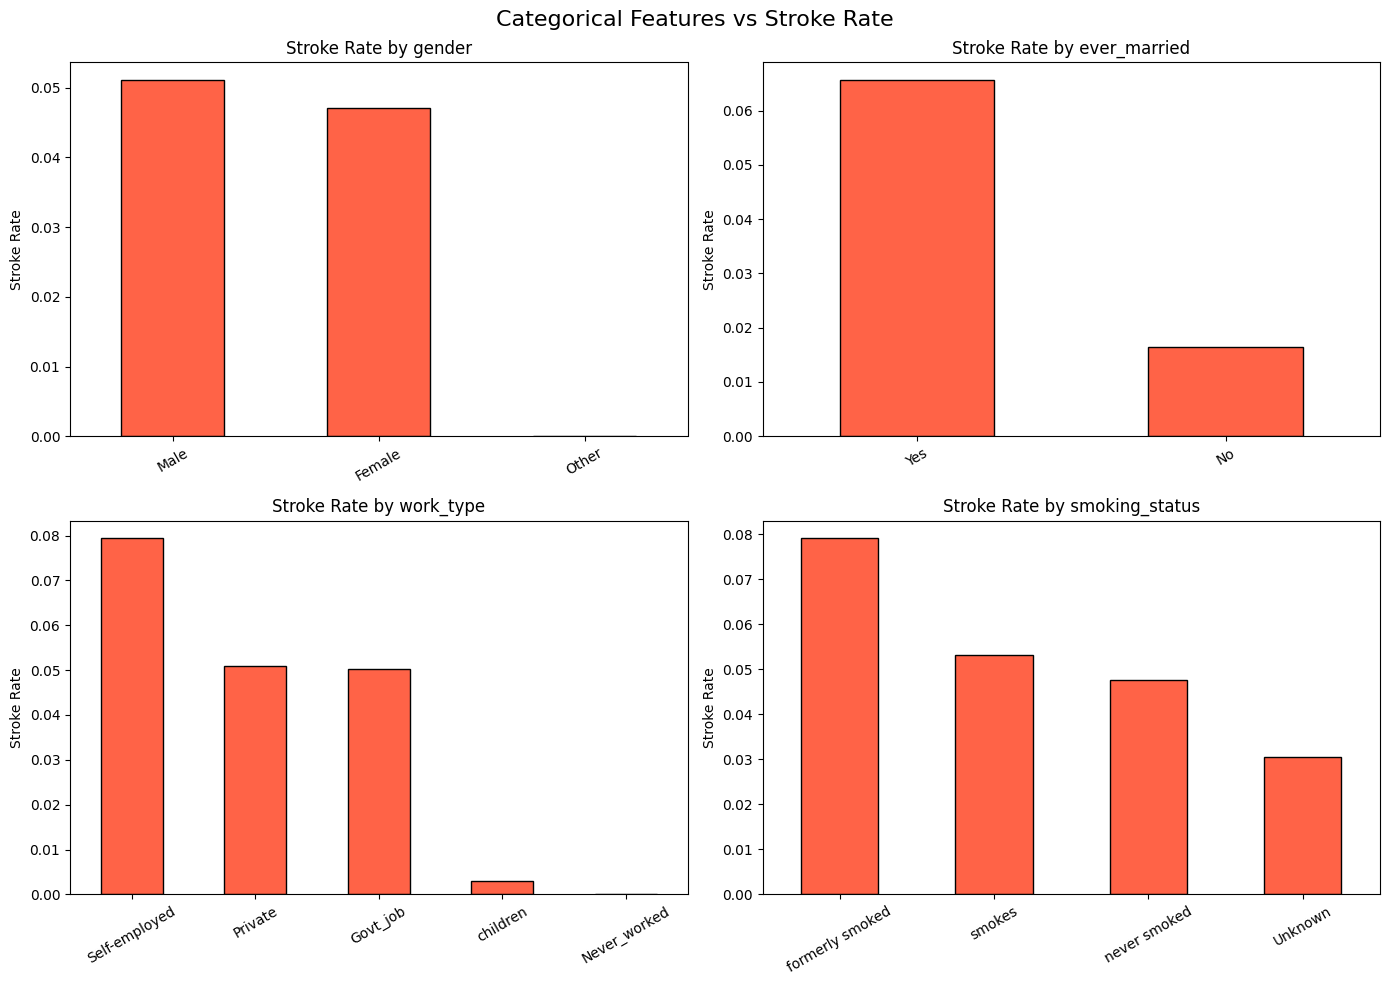

In [114]:
# Categorical features vs stroke
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Categorical Features vs Stroke Rate', fontsize=16)

cat_features = ['gender', 'ever_married', 'work_type', 'smoking_status']
for ax, col in zip(axes.flatten(), cat_features):
    stroke_rate = dp.groupby(col)['stroke'].mean().sort_values(ascending=False)
    stroke_rate.plot(kind='bar', ax=ax, color='tomato', edgecolor='black')
    ax.set_title(f'Stroke Rate by {col}')
    ax.set_ylabel('Stroke Rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

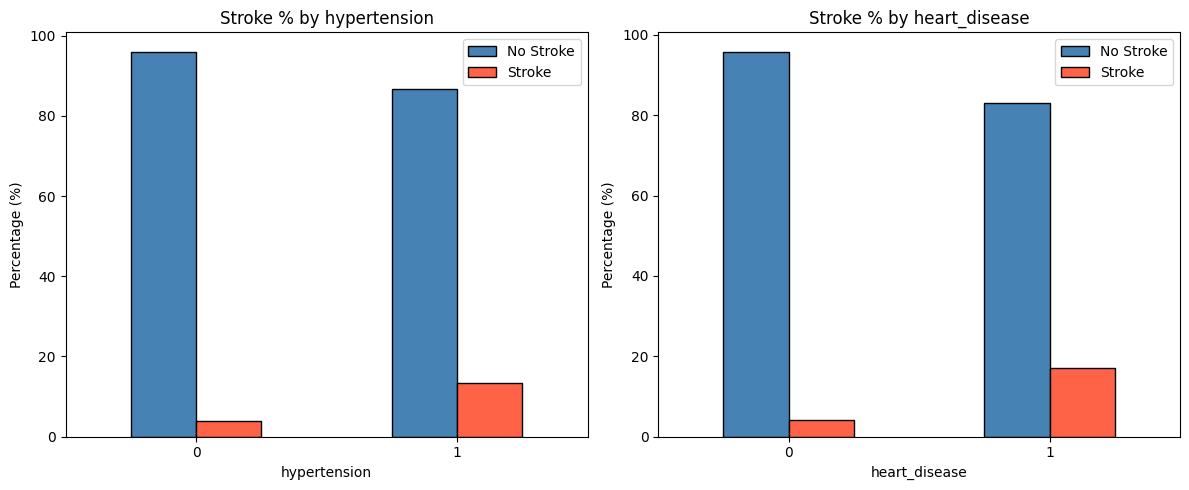

In [115]:
# Hypertension and Heart Disease vs Stroke
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ['hypertension', 'heart_disease']):
    crosstab = pd.crosstab(dp[col], dp['stroke'], normalize='index') * 100
    crosstab.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'],
                  edgecolor='black')
    ax.set_title(f'Stroke % by {col}')
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel(col)
    ax.legend(['No Stroke', 'Stroke'])
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Hypertension and Heart Disease looks like underlying sickness for stroke

Multivariate Analysis

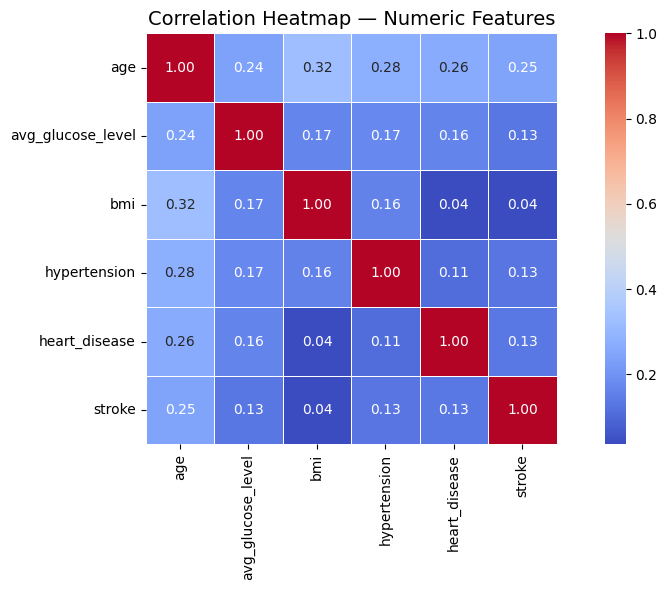

In [116]:
# Correlation heatmap (numeric features only)
plt.figure(figsize=(10, 6))
num_dp = dp[['age', 'avg_glucose_level', 'bmi',
             'hypertension', 'heart_disease', 'stroke']]
corr_matrix = num_dp.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

Observations
Age has the strongest positive correlation with stroke (≈ 0.25)
Hypertension and heart_disease are moderately correlated (≈ 0.11) both co-occur with stroke but are not strongly collinear
BMI and age have a slight positive correlation (≈ 0.33)

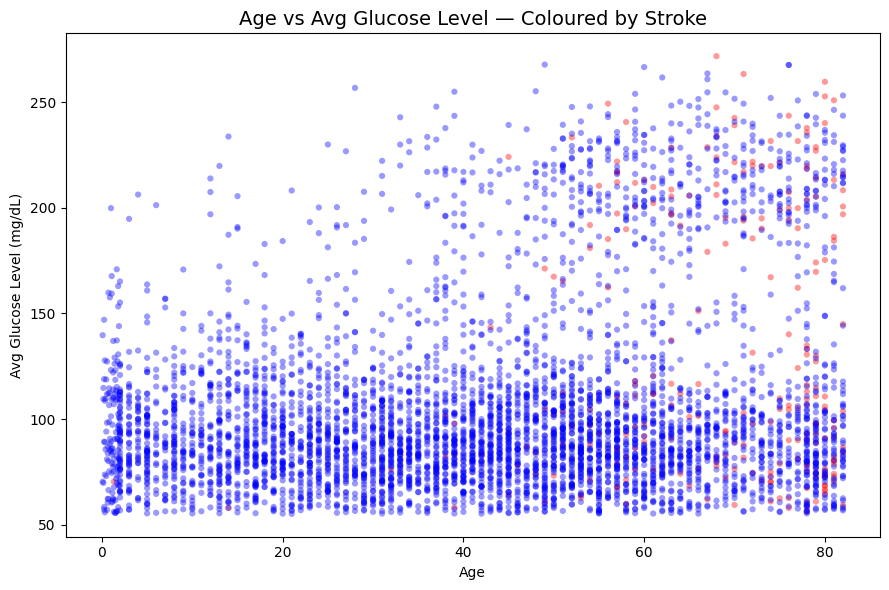

In [117]:
# Age vs Glucose coloured by stroke (most informative combo)
plt.figure(figsize=(9, 6))
colors = dp['stroke'].map({0: 'blue', 1: 'red'})
plt.scatter(dp['age'], dp['avg_glucose_level'],
            c=colors, alpha=0.4, edgecolors='none', s=20)
plt.xlabel('Age')
plt.ylabel('Avg Glucose Level (mg/dL)')
plt.title('Age vs Avg Glucose Level — Coloured by Stroke', fontsize=14)
plt.tight_layout()
plt.show()

Observations
In the scatter plot, stroke cases (red) cluster at older ages and higher glucose levels, these two features together are powerful joint predictors

Outliers detection and treatment

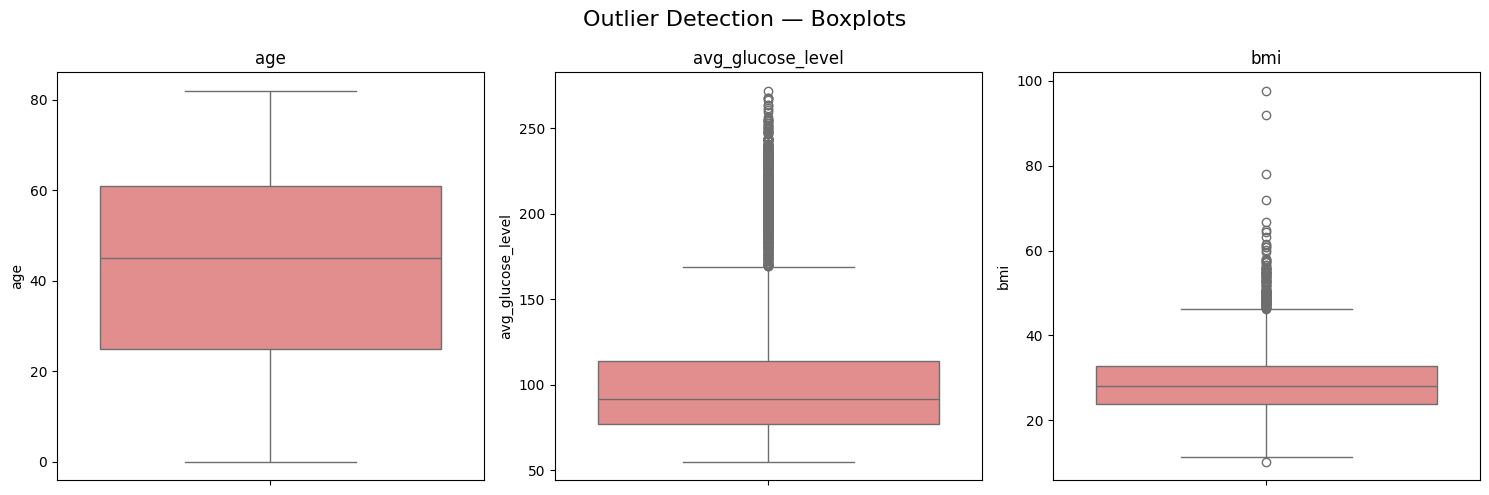

In [118]:
num_cols = ['age', 'avg_glucose_level', 'bmi']

# Boxplots to visualise outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Outlier Detection — Boxplots', fontsize=16)
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=dp[col], ax=ax, color='lightcoral')
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [119]:
for col in num_cols:
    z_scores = np.abs((dp[col] - dp[col].mean()) / dp[col].std())
    outlier_count = (z_scores > 3).sum()
    print(f"  {col}: {outlier_count} outliers")


  age: 0 outliers
  avg_glucose_level: 49 outliers
  bmi: 59 outliers


In [120]:
for col in num_cols:
    Q1 = dp[col].quantile(0.25)
    Q3 = dp[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = dp[(dp[col] < lower) | (dp[col] > upper)]
    print(f"  {col}: {len(outliers)} outliers "
          f"(range: {lower:.2f} – {upper:.2f})")

  age: 0 outliers (range: -29.00 – 115.00)
  avg_glucose_level: 627 outliers (range: 21.98 – 169.36)
  bmi: 126 outliers (range: 10.30 – 46.30)


In [121]:
# Cap BMI and glucose at 99th percentile (Winsorization)
for col in ['avg_glucose_level', 'bmi']:
    cap = dp[col].quantile(0.99)
    dp[col] = dp[col].clip(upper=cap)
    print(f"\n{col} capped at 99th percentile: {cap:.2f}")


avg_glucose_level capped at 99th percentile: 240.71

bmi capped at 99th percentile: 52.89


Observation
BMI has 58 outliers via Z-score; max BMI is 97.6 (extreme obesity)
Glucose has 49 outliers — values up to 271 mg/dL indicate severe diabetes. These are clinically plausible, not data errors.
Age has no statistical outliers — ranges from 0.08 to 82
Decision 
Cap BMI and glucose at 99th percentile (Winsorization) to reduce extreme influence while preserving the data points, since these extremes are medically real and informative

Feature engineering insights
Raw features are rarely in the ideal form for ML models. Based on EDA findings, we encode, transform, and derive new features that better capture the underlying patterns.

In [122]:
dp_eng = dp.copy()

In [123]:
# Drop 'id' — it is an identifier, not a predictor

dp_eng.drop(columns=['id'], inplace=True)


In [124]:
# Remove the single 'Other' gender row

dp_eng = dp_eng[dp_eng['gender'] != 'Other']

In [125]:
dp_eng.shape

(5109, 11)

In [126]:
# Encode binary categorical columns
dp_eng['gender']         = dp_eng['gender'].map({'Male': 1, 'Female': 0})
dp_eng['ever_married']   = dp_eng['ever_married'].map({'Yes': 1, 'No': 0})
dp_eng['Residence_type'] = dp_eng['Residence_type'].map({'Urban': 1, 'Rural': 0})

In [127]:
# Log-transform skewed features to reduce skewness
dp_eng['log_glucose'] = np.log1p(dp_eng['avg_glucose_level'])
dp_eng['log_bmi']     = np.log1p(dp_eng['bmi'])

In [128]:
# One-hot encode multi-class categorical columns
dp_eng = pd.get_dummies(dp_eng,
                        columns=['work_type', 'smoking_status'],
                        drop_first=True)

In [129]:
# Derive new features based on EDA observations
dp_eng['age_glucose_interaction'] = dp_eng['age'] * dp_eng['avg_glucose_level']
dp_eng['risk_score'] = (
    dp_eng['hypertension'] +
    dp_eng['heart_disease'] +
    (dp_eng['age'] > 60).astype(int) +
    (dp_eng['avg_glucose_level'] > 140).astype(int)
)

In [130]:
# Age group feature
dp_eng['age_group'] = pd.cut(dp_eng['age'],
                             bins=[0, 18, 40, 60, 100],
                             labels=['Child', 'Young Adult',
                                     'Middle Age', 'Senior'])
dp_eng = pd.get_dummies(dp_eng, columns=['age_group'], drop_first=True)

In [ ]:
dp_eng

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,log_glucose,...,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,age_glucose_interaction,risk_score,age_group_Young Adult,age_group_Middle Age,age_group_Senior
0,1,67.0,0,1,1,1,228.69,36.6,1,5.436731,...,False,False,True,False,False,15322.23,3,False,False,True
1,0,61.0,0,0,1,0,202.21,28.1,1,5.314240,...,True,False,False,True,False,12334.81,2,False,False,True
2,1,80.0,0,1,1,0,105.92,32.5,1,4.672081,...,False,False,False,True,False,8473.60,2,False,False,True
3,0,49.0,0,0,1,1,171.23,34.4,1,5.148831,...,False,False,False,False,True,8390.27,1,False,True,False
4,0,79.0,1,0,1,0,174.12,24.0,1,5.165471,...,True,False,False,True,False,13755.48,3,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,0,80.0,1,0,1,1,83.75,28.1,0,4.439706,...,False,False,False,True,False,6700.00,2,False,False,True
5106,0,81.0,0,0,1,1,125.20,40.0,0,4.837868,...,True,False,False,True,False,10141.20,1,False,False,True
5107,0,35.0,0,0,1,0,82.99,30.6,0,4.430698,...,True,False,False,True,False,2904.65,0,True,False,False
5108,1,51.0,0,0,1,0,166.29,25.6,0,5.119729,...,False,False,True,False,False,8480.79,1,False,True,False


,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,log_glucose,...,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,age_glucose_interaction,risk_score,age_group_Young Adult,age_group_Middle Age,age_group_Senior
0,1,67.0,0,1,1,1,228.69,36.6,1,5.436731,...,False,False,True,False,False,15322.23,3,False,False,True
1,0,61.0,0,0,1,0,202.21,28.1,1,5.314240,...,True,False,False,True,False,12334.81,2,False,False,True
2,1,80.0,0,1,1,0,105.92,32.5,1,4.672081,...,False,False,False,True,False,8473.60,2,False,False,True
3,0,49.0,0,0,1,1,171.23,34.4,1,5.148831,...,False,False,False,False,True,8390.27,1,False,True,False
4,0,79.0,1,0,1,0,174.12,24.0,1,5.165471,...,True,False,False,True,False,13755.48,3,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,0,80.0,1,0,1,1,83.75,28.1,0,4.439706,...,False,False,False,True,False,6700.00,2,False,False,True
5106,0,81.0,0,0,1,1,125.20,40.0,0,4.837868,...,True,False,False,True,False,10141.20,1,False,False,True
5107,0,35.0,0,0,1,0,82.99,30.6,0,4.430698,...,True,False,False,True,False,2904.65,0,True,False,False
5108,1,51.0,0,0,1,0,166.29,25.6,0,5.119729,...,False,False,True,False,False,8480.79,1,False,True,False


In [ ]:
#Engineered dataset summary
print(f"Shape: {dp_eng.shape}")
print(f"\nAll columns:\n{dp_eng.columns.tolist()}")
print(f"\nRemaining missing values: {dp_eng.isnull().sum().sum()}")

Shape: (5109, 23)

All columns:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'stroke', 'log_glucose', 'log_bmi', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes', 'age_glucose_interaction', 'risk_score', 'age_group_Young Adult', 'age_group_Middle Age', 'age_group_Senior']

Remaining missing values: 0



'id' dropped: no predictive value
Binary encoding for gender, ever_married, Residence_type
One-hot encoding for work_type and smoking_status (multi-class)
Log transform applied to right-skewed glucose and BMI
age_glucose_interaction captures the joint high-risk pattern seen in Step 7's scatter plot
risk_score aggregates clinical risk factors into one feature
age_group converts continuous age into clinical categories (children rarely have stroke — the age-stroke link is non-linear)

In [ ]:
X = dp_eng.drop(columns=['stroke'])
y = dp_eng['stroke']

print(f"Features (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"\nStroke rate: {y.mean()*100:.2f}%")

Features (X) shape : (5109, 22)
Target   (y) shape : (5109,)

Target distribution:
stroke
0    4860
1     249
Name: count, dtype: int64

Stroke rate: 4.87%


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"\nStroke rate in train : {y_train.mean()*100:.2f}%")
print(f"Stroke rate in test  : {y_test.mean()*100:.2f}%")

X_train : (4087, 22)
X_test  : (1022, 22)

Stroke rate in train : 4.87%
Stroke rate in test  : 4.89%


In [132]:
from sklearn.preprocessing import StandardScaler

In [133]:


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform train
X_test_scaled  = scaler.transform(X_test)         # transform only (no fit)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print("Scaling complete.")
print("\nSample means after scaling (should be ~0):")
print(X_train_scaled[['age', 'avg_glucose_level', 'bmi']].mean().round(4))
print("\nSample stds after scaling (should be ~1):")
print(X_train_scaled[['age', 'avg_glucose_level', 'bmi']].std().round(4))

Scaling complete.

Sample means after scaling (should be ~0):
age                 -0.0
avg_glucose_level   -0.0
bmi                 -0.0
dtype: float64

Sample stds after scaling (should be ~1):
age                  1.0001
avg_glucose_level    1.0001
bmi                  1.0001
dtype: float64
